In [46]:
# RandomForest -

# Import packages and load dataset.
import pandas as pd
from sklearn.model_selection import train_test_split

file_path = r"../Rice_Cammeo_Osmancik.xlsx"
df = pd.read_excel(file_path)

In [47]:
# Split dataframe into dependent and independent features
independent = df.drop('Class', axis=1)  # Features (all columns except the target)
dependent = df['Class']

In [48]:
# Split dataframe into test and train sets
independent_train, independent_test, dependent_train, dependent_test = train_test_split(independent, dependent, test_size=0.2, random_state=42)

In [49]:
from sklearn.ensemble import RandomForestClassifier

features = ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length',
       'Eccentricity', 'Convex_Area', 'Extent']
X = pd.get_dummies(independent_train[features])
X_test = pd.get_dummies(independent_test[features])

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(independent_train, dependent_train)
predictions = model.predict(independent_test)


In [50]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(dependent_test, predictions))

Accuracy: 0.9304461942257218


In [51]:
past_accuracy = 0
best_accuracy = 0
for i in range(100):
    model = RandomForestClassifier(n_estimators=100, max_depth=i+1, random_state=1)
    model.fit(independent_train, dependent_train)
    predictions = model.predict(independent_test)
    accuracy = accuracy_score(dependent_test, predictions)


    if past_accuracy == accuracy :
        change = 'No Change'
    elif accuracy > past_accuracy:
        change = 'Increase'
    else:
        change = 'Decrease'

    print("Depth of" ,i+1, "Accuracy:", round(accuracy,4), " Change of: ", change)
    past_accuracy = accuracy

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_depth = i+1

print("Best Accuracy is: ", best_accuracy, " Best Depth is: ", best_depth)

Depth of 1 Accuracy: 0.9226  Change of:  Increase
Depth of 2 Accuracy: 0.9304  Change of:  Increase
Depth of 3 Accuracy: 0.9331  Change of:  Increase
Depth of 4 Accuracy: 0.9304  Change of:  Decrease
Depth of 5 Accuracy: 0.9304  Change of:  No Change
Depth of 6 Accuracy: 0.9265  Change of:  Decrease
Depth of 7 Accuracy: 0.9239  Change of:  Decrease
Depth of 8 Accuracy: 0.9226  Change of:  Decrease
Depth of 9 Accuracy: 0.9199  Change of:  Decrease
Depth of 10 Accuracy: 0.9252  Change of:  Increase
Depth of 11 Accuracy: 0.9252  Change of:  No Change
Depth of 12 Accuracy: 0.9252  Change of:  No Change
Depth of 13 Accuracy: 0.9213  Change of:  Decrease
Depth of 14 Accuracy: 0.9252  Change of:  Increase
Depth of 15 Accuracy: 0.9239  Change of:  Decrease
Depth of 16 Accuracy: 0.9213  Change of:  Decrease
Depth of 17 Accuracy: 0.9186  Change of:  Decrease
Depth of 18 Accuracy: 0.9199  Change of:  Increase
Depth of 19 Accuracy: 0.9213  Change of:  Increase
Depth of 20 Accuracy: 0.9213  Change 

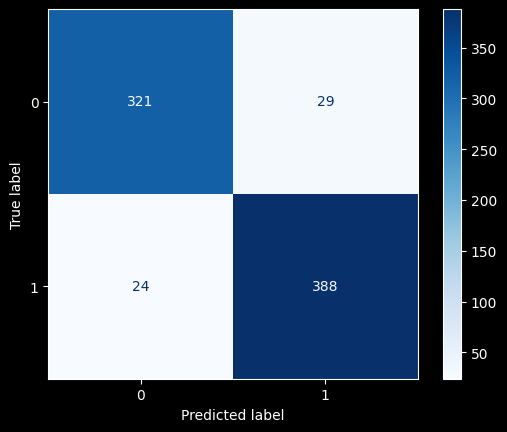

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(dependent_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()